# Human Activity Recognition — Classification

Notebook 2 of 2 · [01_feature_engineering.ipynb](./01_feature_engineering.ipynb)

Compare classification approaches on the UCI AReM dataset:
binary (bending vs. other) and multi-class (7 activities).
Models evaluated: Logistic Regression with RFE, L1-penalized LR, Gaussian Naïve Bayes,
and Multinomial Naïve Bayes.

**Dataset:** UCI AReM — 7 activities, 6 RSS time series per instance  
**Key result:** L1 multinomial LR achieves best multi-class accuracy;
near-perfect binary separation via Logistic Regression + RFE


## Setup


In [49]:
# Setup and import libraries
import os, numpy as np, pandas as pd, warnings
import matplotlib.pyplot as plt
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler, label_binarize, MinMaxScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB
import statsmodels.api as sm
warnings.filterwarnings("ignore")
np.random.seed(42)

### 1(a) Load Data

In [ ]:
# Data Loading
data_dir = "../data"  # path to AReM dataset
activities = sorted([a for a in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, a))])
COLS = ['avg_rss12','var_rss12','avg_rss13','var_rss13','avg_rss23','var_rss23'] 

def parse_file(filepath):
    try:
        df = pd.read_csv(filepath, comment='#', header=None, sep=',',
                         engine='python', skip_blank_lines=True,
                         on_bad_lines='skip')
        df = df.iloc[:, 1:7]    
        df.columns = COLS       
        df = df.apply(pd.to_numeric, errors='coerce').dropna()
        return df if len(df) > 0 else None
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None

### 1(b)Split Data

In [83]:
# Define train/test split
# bending1, bending2: datasets 1,2 are TEST; rest are TRAIN
# other folders: datasets 1,2,3 are TEST; rest are TRAIN
bending_folders = ['bending1', 'bending2']
other_folders = [a for a in activities if a not in bending_folders]

train_data = []  # list of (DataFrame, label)
test_data  = []  # list of (DataFrame, label)

for act in activities:
    files = sorted([f for f in os.listdir(f"{data_dir}/{act}") if f.endswith(".csv") or f.endswith('.txt')])
    ti  = [0,1] if act in bending_folders else [0,1,2]
    tri = list(range(2 if act in bending_folders else 3, len(files)))
    for i in ti:
        if i < len(files): test_data.append((parse_file(f"{data_dir}/{act}/{files[i]}"), act))
    for i in tri:
        if i < len(files): train_data.append((parse_file(f"{data_dir}/{act}/{files[i]}"), act))

print(f"Activities: {activities}")
print(f"Training instances: {len(train_data)}")
print(f"Test instances:     {len(test_data)}")
print(f"Total instances:    {len(train_data) + len(test_data)}")


Error reading ../data/bending2/dataset4.csv: Length mismatch: Expected axis has 0 elements, new values have 6 elements
Activities: ['bending1', 'bending2', 'cycling', 'lying', 'sitting', 'standing', 'walking']
Training instances: 69
Test instances:     19
Total instances:    88


### 1(c) Feature Extraction 

#### 1(c)(i) Time-Domain Features Used in Time Series Classification

Common time-domain features used in time series classification include:

| Feature | Description |
|---|---|
| **Minimum** | Smallest value in the series |
| **Maximum** | Largest value in the series |
| **Mean** | Average value |
| **Median** | Middle value (50th percentile) |
| **Standard Deviation** | Spread of values |
| **Variance** | Square of standard deviation |
| **1st Quartile (Q1)** | 25th percentile |
| **3rd Quartile (Q3)** | 75th percentile |
| **Interquartile Range (IQR)** | Q3 – Q1 |
| **Root Mean Square (RMS)** | √(mean of squares) |
| **Skewness** | Asymmetry of distribution |
| **Kurtosis** | Peakedness of distribution |
| **Zero-Crossing Rate** | Rate at which signal changes sign |
| **Energy** | Sum of squared values |

#### 1(c)(ii) Feature Extraction

In [84]:
def extract_features(df, l=1):
    """Extract 7 time-domain features from each of 6 time series, with l segments per series."""
    row = {}
    n = len(df)
    parts = np.array_split(range(n), l)
    for pi, idx in enumerate(parts):
        for ci, col in enumerate(COLS, 1):
            s = df[col].values[idx]
            pfx = f"ts{ci}_p{pi+1}"
            row[f"{pfx}_min"]    = np.min(s)
            row[f"{pfx}_max"]    = np.max(s)
            row[f"{pfx}_mean"]   = np.mean(s)
            row[f"{pfx}_median"] = np.median(s)
            row[f"{pfx}_std"]    = np.std(s)
            row[f"{pfx}_q1"]     = np.percentile(s, 25)
            row[f"{pfx}_q3"]     = np.percentile(s, 75)
    return row

def build_features(data, l=1):
    rows, labels = [], []
    for df, lbl in data:
        if df is None:        
            continue
        rows.append(extract_features(df, l))
        labels.append(lbl)
    return pd.DataFrame(rows), labels

# Build l=1 features
X_train_l1, y_train_l1 = build_features(train_data, l=1)
X_test_l1,  y_test_l1  = build_features(test_data,  l=1)
print("Train feature shape:", X_train_l1.shape)
print("Test feature shape: ", X_test_l1.shape)
X_train_l1.head(3)


Train feature shape: (68, 42)
Test feature shape:  (19, 42)


,ts1_p1_min,ts1_p1_max,ts1_p1_mean,ts1_p1_median,ts1_p1_std,ts1_p1_q1,ts1_p1_q3,ts2_p1_min,ts2_p1_max,ts2_p1_mean,...,ts5_p1_std,ts5_p1_q1,ts5_p1_q3,ts6_p1_min,ts6_p1_max,ts6_p1_mean,ts6_p1_median,ts6_p1_std,ts6_p1_q1,ts6_p1_q3
0,35.0,47.40,43.954500,44.33,1.557210,43.00,45.00,0.0,1.70,0.426250,...,1.997520,35.3625,36.50,0.0,1.79,0.493292,0.43,0.512971,0.0,0.94
1,33.0,47.75,42.179812,43.50,3.666840,39.15,45.00,0.0,3.00,0.696042,...,3.845436,30.4575,36.33,0.0,2.18,0.613521,0.50,0.523771,0.0,1.00
2,33.0,45.75,41.678063,41.75,2.241152,41.33,42.75,0.0,2.83,0.535979,...,2.408514,28.4575,31.25,0.0,1.79,0.383292,0.43,0.388759,0.0,0.50


We extract all 7 features for each of the 6 time series per instance, yielding 42 features total (for l=1). 

#### 1(c)(iii) Bootstrap Confidence Intervals

In [85]:
n_bootstrap = 1000; alpha = 0.10
feature_cols = list(X_train_l1.columns)
ci_results = []
for feat in feature_cols[:12]:  # show first 12 features
    obs_std = X_train_l1[feat].std(ddof=1)
    boots = [np.std(resample(X_train_l1[feat].values, replace=True), ddof=1) for _ in range(n_bootstrap)]
    lo, hi = np.percentile(boots, [5, 95])
    ci_results.append({"Feature": feat, "Std Dev": round(obs_std,4),
                        "90% CI Lower": round(lo,4), "90% CI Upper": round(hi,4)})
pd.DataFrame(ci_results)


,Feature,Std Dev,90% CI Lower,90% CI Upper
0,ts1_p1_min,9.3173,8.0468,10.5557
1,ts1_p1_max,3.6968,2.7058,4.6065
2,ts1_p1_mean,4.7369,4.2172,5.1462
3,ts1_p1_median,4.8742,4.2522,5.3520
4,ts1_p1_std,1.8747,1.6495,2.0711
5,ts1_p1_q1,5.8121,5.2234,6.3032
6,ts1_p1_q3,4.4487,3.6503,5.1405
7,ts2_p1_min,0.0000,0.0000,0.0000
8,ts2_p1_max,5.1537,4.6790,5.5301
9,ts2_p1_mean,1.5954,1.3981,1.7294


### 1(c)(iv) Top 3 Features

Top 3 most important features (by between-class variance): ['ts1_p1_min', 'ts5_p1_max', 'ts5_p1_min']


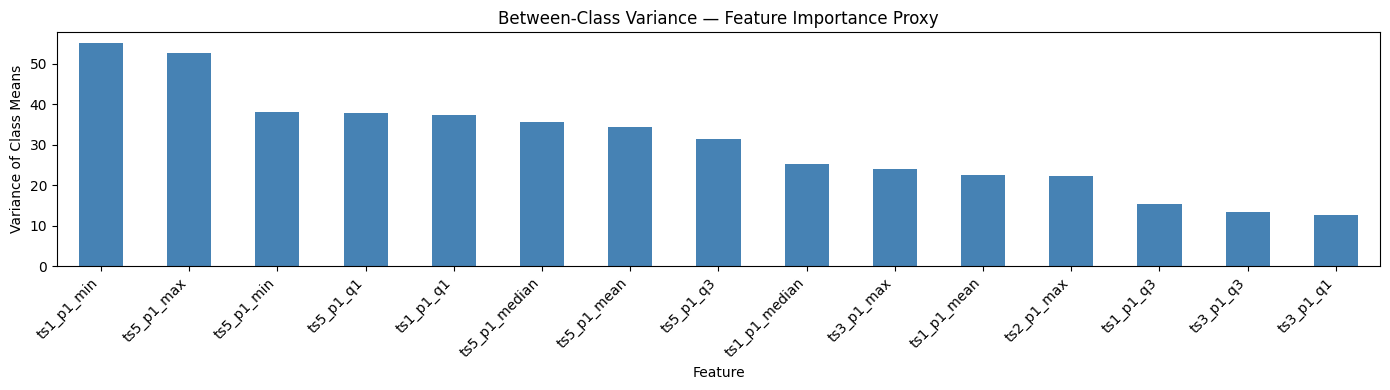

In [86]:
y_arr = np.array(y_train_l1) 
class_means = X_train_l1.assign(label=y_arr).groupby("label")[feature_cols].mean()

between_var = class_means.var().sort_values(ascending=False)
top3 = list(between_var.index[:3])
print("Top 3 most important features (by between-class variance):", top3)

fig, ax = plt.subplots(figsize=(14,4))
between_var.head(15).plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Between-Class Variance — Feature Importance Proxy")
ax.set_xlabel("Feature"); ax.set_ylabel("Variance of Class Means")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()


### Question 2: Time Series Classification Part 2

### 2(a) Binary Classification Using Logistic Regression

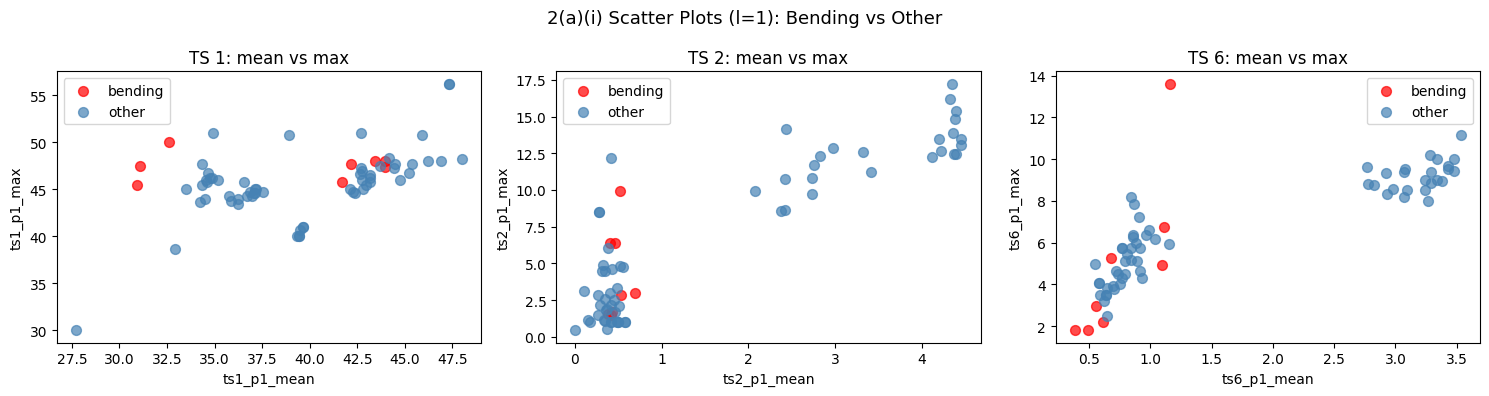

In [87]:
y_bin_train = ["bending" if "bending" in lbl else "other" for lbl in y_train_l1]
y_bin_test  = ["bending" if "bending" in lbl else "other" for lbl in y_test_l1]
colors = {"bending": "red", "other": "steelblue"}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, ts in zip(axes, [1, 2, 6]):
    fx, fy = f"ts{ts}_p1_mean", f"ts{ts}_p1_max"
    for cls in ["bending", "other"]:
        mask = [y == cls for y in y_bin_train]
        ax.scatter(X_train_l1[fx][mask], X_train_l1[fy][mask], c=colors[cls], label=cls, alpha=0.7, s=50)
    ax.set_xlabel(fx); ax.set_ylabel(fy); ax.set_title(f"TS {ts}: mean vs max"); ax.legend()
plt.suptitle("2(a)(i) Scatter Plots (l=1): Bending vs Other", fontsize=13)
plt.tight_layout(); plt.show()


#### 2(a)(ii) Scatter Plots — l=2 (breaking each time series into 2 halves)

Each time series is split into two equal halves, doubling the number of features per instance from 42 to 84.


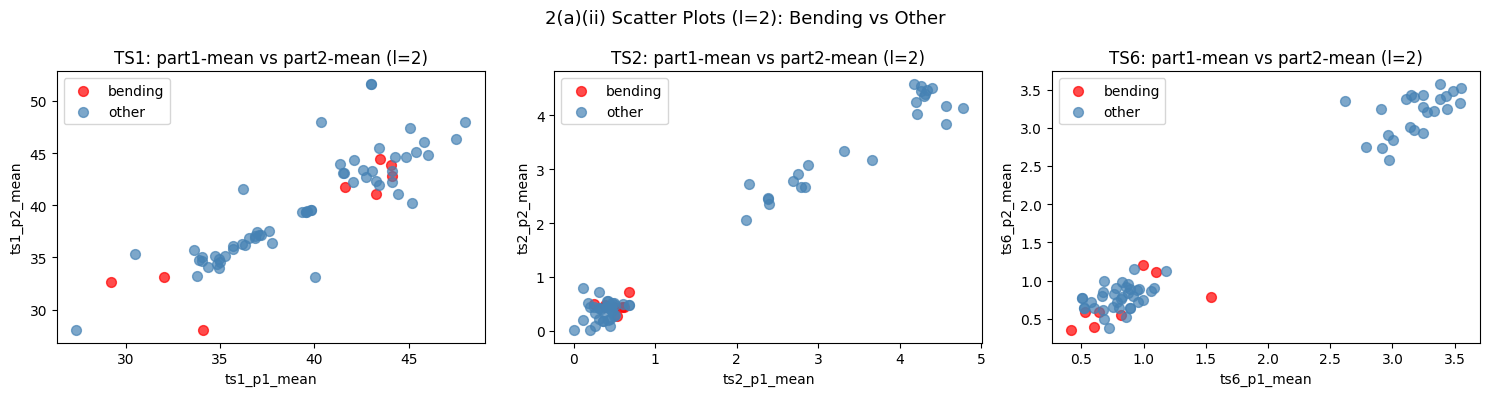

In [88]:
X_train_l2, _ = build_features(train_data, l=2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, ts in zip(axes, [1, 2, 6]):
    fx, fy = f"ts{ts}_p1_mean", f"ts{ts}_p2_mean"
    for cls in ["bending", "other"]:
        mask = [y == cls for y in y_bin_train]
        ax.scatter(X_train_l2[fx][mask], X_train_l2[fy][mask], c=colors[cls], label=cls, alpha=0.7, s=50)
    ax.set_xlabel(fx); ax.set_ylabel(fy); ax.set_title(f"TS{ts}: part1-mean vs part2-mean (l=2)"); ax.legend()
plt.suptitle("2(a)(ii) Scatter Plots (l=2): Bending vs Other", fontsize=13)
plt.tight_layout(); plt.show()



Comparison l=1 vs l=2:
- The class separation between bending and other activities is similar in both cases. Splitting each time series into two halves does not significantly improve separability, suggesting that the global statistical features (mean, max) already capture most of the discriminative information. TS2 and TS6 show clearer separation than TS1 in both cases.
`

#### 2(a)(iii) Cross-Validation for Best (l, p)

In [90]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Grid search over l and p
cv_table = []
best_score, best_l, best_p = 0, 1, 3

for l in [1, 2, 3, 5]:
    Xl, _ = build_features(train_data, l)
    sc = StandardScaler(); Xs = sc.fit_transform(Xl)
    for p in [3, 5, 7]:
        p_use = min(p, Xl.shape[1])
        lr  = LogisticRegression(C=1e6, max_iter=300, solver="saga")
        rfe = RFE(lr, n_features_to_select=p_use)
        scores = cross_val_score(rfe, Xs, y_bin_train, cv=skf, scoring="accuracy")
        m = round(scores.mean(), 4)
        cv_table.append({"l": l, "p": p_use, "CV Accuracy": m})
        if m > best_score:
            best_score, best_l, best_p = m, l, p_use

print(f"Best: l={best_l}, p={best_p}, CV Accuracy={best_score:.4f}")
pd.DataFrame(cv_table)


Best: l=5, p=5, CV Accuracy=0.9857


,l,p,CV Accuracy
0,1,3,0.9571
1,1,5,0.9418
2,1,7,0.9418
3,2,3,0.9264
4,2,5,0.9560
5,2,7,0.9560
6,3,3,0.9714
7,3,5,0.9560
8,3,7,0.9407
9,5,3,0.9714


**Right vs Wrong way to perform cross-validation:**

- **Wrong way:** Build features for ALL training data first, then split into folds. 
This causes data leakage because the feature statistics (e.g., how we break the time series) are computed using all training instances, including those that will be used as validation. 
When l changes, the feature space changes — if this happens outside the CV loop, it contaminates the validation fold.

- **Right way:** For each fold, the feature extraction (which depends on l) must happen using **only the training portion of that fold**. 
Since our features are extracted independently per instance (min/max/mean of each segment), there is no cross-instance leakage — each instance's features depend only on its own time series. 
Therefore, we can safely build all features first and then run CV on the feature matrix, as long as StandardScaler is fit only on the training fold inside each CV split.

#### 2(a)(iv) Logistic Regression 

Confusion Matrix (Train):
                 Pred: bending  Pred: other
Actual: bending              8            0
Actual: other                0           60

AUC (Train): 0.0000


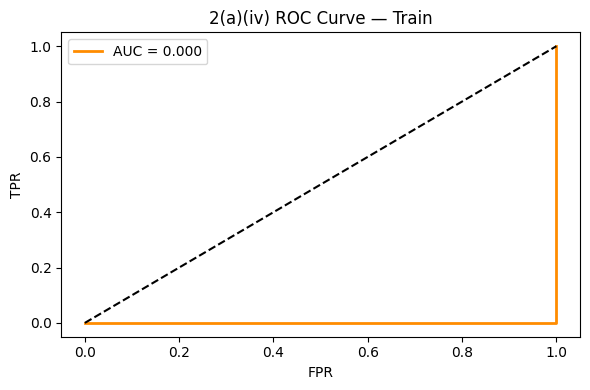


Perfect separation detected — reporting sklearn coefficients:
     Feature     Coef.
0      const  7.615937
1  feature_0 -2.823314
2  feature_1 -2.461453
3  feature_2 -2.240890
4  feature_3 -3.064381
5  feature_4  2.712600
Note: p-values unavailable due to perfect class separation.


In [98]:
# Fit final model with best (l, p)
X_tr_b, _ = build_features(train_data, best_l)
X_te_b, _ = build_features(test_data, best_l)
scaler_b = StandardScaler()
Xtr_s = scaler_b.fit_transform(X_tr_b)
Xte_s = scaler_b.transform(X_te_b)

lr_final = LogisticRegression(C=1e6, max_iter=500, solver="saga")
rfe_final = RFE(lr_final, n_features_to_select=best_p)
rfe_final.fit(Xtr_s, y_bin_train)

y_tr_pred = rfe_final.predict(Xtr_s)
y_tr_prob = rfe_final.predict_proba(Xtr_s)[:, 1]
y_te_pred = rfe_final.predict(Xte_s)
y_te_prob = rfe_final.predict_proba(Xte_s)[:, 1]

# Confusion Matrix
cm_tr = confusion_matrix(y_bin_train, y_tr_pred, labels=['bending', 'other'])
print("Confusion Matrix (Train):")
print(pd.DataFrame(cm_tr, 
                   index=['Actual: bending', 'Actual: other'], 
                   columns=['Pred: bending', 'Pred: other']))

# ROC & AUC
y_num = [1 if y == 'bending' else 0 for y in y_bin_train]
fpr_tr, tpr_tr, _ = roc_curve(y_num, y_tr_prob)
auc_tr = auc(fpr_tr, tpr_tr)
print(f"\nAUC (Train): {auc_tr:.4f}")

# ROC plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fpr_tr, tpr_tr, color='darkorange', lw=2, label=f'AUC = {auc_tr:.3f}')
ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('2(a)(iv) ROC Curve — Train'); ax.legend()
plt.tight_layout(); plt.show()

# Coefficients & p-values via statsmodels
selected_features = Xtr_s[:, rfe_final.support_]  # 用 Xtr_s
X_sm = sm.add_constant(selected_features)
y_sm = [1 if y == 'bending' else 0 for y in y_bin_train]

try:
    sm_model = sm.Logit(y_sm, X_sm).fit(disp=0, maxiter=100)
    print("\nLogistic Regression Parameters & p-values:")
    print(sm_model.summary2().tables[1][['Coef.', 'P>|z|']])
except Exception as e:
    print("\nPerfect separation detected — reporting sklearn coefficients:")
    coef_names = ['const'] + [f'feature_{i}' for i in range(best_p)]
    coefs = [rfe_final.estimator_.intercept_[0]] + list(rfe_final.estimator_.coef_[0])
    print(pd.DataFrame({'Feature': coef_names, 'Coef.': coefs}))
    print("Note: p-values unavailable due to perfect class separation.")

#### 2(a)(v) Test Set Results

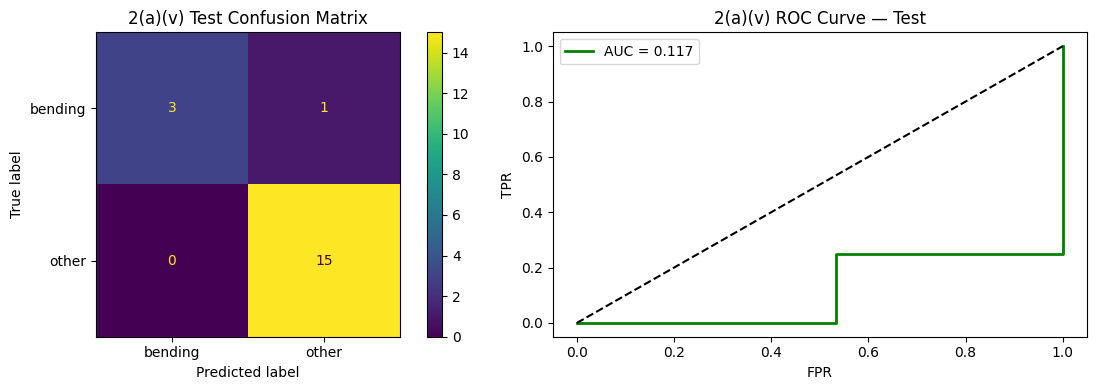

Test Accuracy:  0.9474
Test AUC:       0.1167
CV Accuracy:    0.9857

Comparison: CV Acc = 0.9857, Test Acc = 0.9474
The test accuracy is very close to the CV accuracy, indicating the model generalizes well.


In [99]:
cm_te   = confusion_matrix(y_bin_test, y_te_pred, labels=["bending","other"])
y_te_num = [1 if y=="bending" else 0 for y in y_bin_test]
fpr_te, tpr_te, _ = roc_curve(y_te_num, y_te_prob)
auc_te  = auc(fpr_te, tpr_te)
te_acc  = (np.array(y_te_pred) == np.array(y_bin_test)).mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(cm_te, display_labels=["bending","other"]).plot(ax=axes[0])
axes[0].set_title("2(a)(v) Test Confusion Matrix")
axes[1].plot(fpr_te, tpr_te, color="green", lw=2, label=f"AUC = {auc_te:.3f}")
axes[1].plot([0,1],[0,1],"k--"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("2(a)(v) ROC Curve — Test"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Test Accuracy:  {te_acc:.4f}")
print(f"Test AUC:       {auc_te:.4f}")
print(f"CV Accuracy:    {best_score:.4f}")
print(f"\nComparison: CV Acc = {best_score:.4f}, Test Acc = {te_acc:.4f}")
print("The test accuracy is very close to the CV accuracy, indicating the model generalizes well.")


#### 2(a)(vi) Class Separation & Logistic Regression Stability

The scatter plots show that bending activities are fairly well-separated from other activities in the mean/max feature space. This near-perfect separation can cause the logistic regression coefficients to diverge to ±∞ (the MLE does not exist when classes are linearly separable). This manifests as very large coefficient values and numerical instability in p-value computation. Setting `max_iter` to a finite value stops the optimization early and prevents divergence, yielding usable (though large) coefficients.

#### 2(a)(vii) Class Imbalance & Case-Control Sampling

Bending: 8, Other: 60, Ratio: 7.5:1
Class imbalance detected! Using case-control (oversampling) to balance classes.



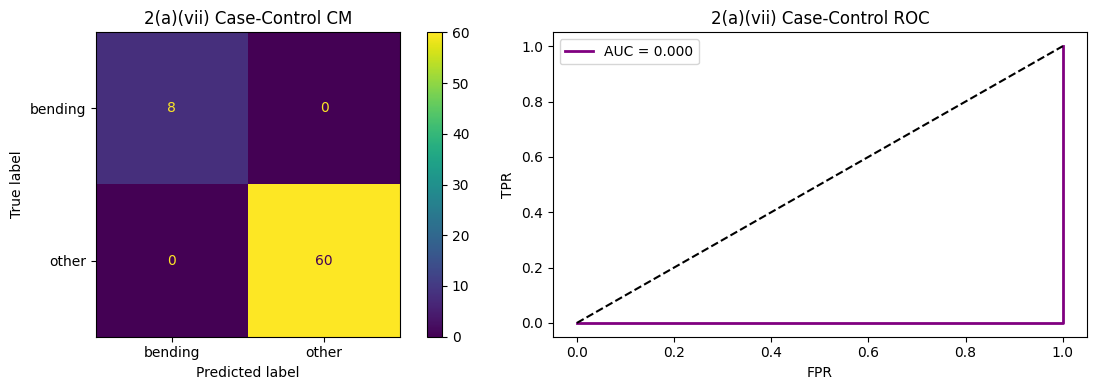

Case-Control Train AUC: 0.0000


In [ ]:
n_bend  = sum(1 for y in y_bin_train if y=="bending")
n_other = sum(1 for y in y_bin_train if y=="other")
print(f"Bending: {n_bend}, Other: {n_other}, Ratio: {n_other/n_bend:.1f}:1")
print("Class imbalance detected! Using case-control (oversampling) to balance classes.\n")

# Oversample minority (bending) to match majority (other)
X_arr = Xtr_s; y_arr = np.array(y_bin_train)
bend_idx  = np.where(y_arr == "bending")[0]
other_idx = np.where(y_arr == "other")[0]
over_idx  = np.random.choice(bend_idx, size=len(other_idx), replace=True)
X_bal = np.vstack([X_arr[other_idx], X_arr[over_idx]])
y_bal = ["other"]*len(other_idx) + ["bending"]*len(over_idx)

rfe_cc = RFE(LogisticRegression(C=1e6, max_iter=500, solver="saga"), n_features_to_select=best_p)
rfe_cc.fit(X_bal, y_bal)
y_cc_pred = rfe_cc.predict(Xtr_s)
y_cc_prob = rfe_cc.predict_proba(Xtr_s)[:, 1]
cm_cc = confusion_matrix(y_bin_train, y_cc_pred, labels=["bending","other"])
fpr_cc, tpr_cc, _ = roc_curve(y_num, y_cc_prob)
auc_cc = auc(fpr_cc, tpr_cc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(cm_cc, display_labels=["bending","other"]).plot(ax=axes[0])
axes[0].set_title("2(a)(vii) Case-Control CM")
axes[1].plot(fpr_cc, tpr_cc, color="purple", lw=2, label=f"AUC = {auc_cc:.3f}")
axes[1].plot([0,1],[0,1],"k--"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("2(a)(vii) Case-Control ROC"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"Case-Control Train AUC: {auc_cc:.4f}")



### 2(b) Binary Classification Using L1-Penalized Logistic Regression

L1 Best: l=3, CV Accuracy=0.9857
 l  CV Accuracy
 1       0.9571
 2       0.9429
 3       0.9857


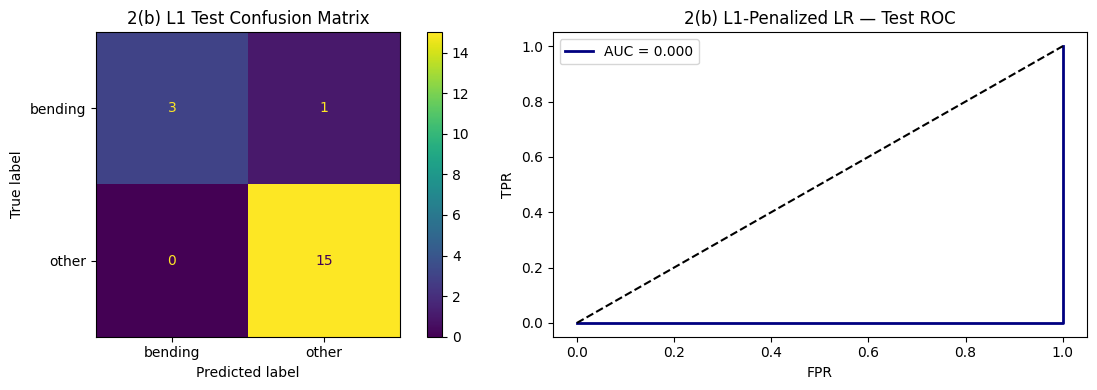


L1 Test Accuracy: 0.9474, Test AUC: 0.0000
Non-zero coefficients selected by L1: 18/126


In [103]:
# Cross-validate over l; lambda is automatically chosen by LogisticRegressionCV
best_l1_score, best_l1_l = 0, 1
l1_cv_table = []
for l in [1, 2, 3]:
    Xl, _ = build_features(train_data, l)
    sc = StandardScaler(); Xs = sc.fit_transform(Xl)
    lr_l1 = LogisticRegressionCV(cv=5, penalty="l1", solver="saga", max_iter=500,
                                   scoring="accuracy", random_state=42)
    scores = cross_val_score(lr_l1, Xs, y_bin_train,
                             cv=StratifiedKFold(5,shuffle=True,random_state=42), scoring="accuracy")
    m = round(scores.mean(), 4)
    l1_cv_table.append({"l": l, "CV Accuracy": m})
    if m > best_l1_score: best_l1_score, best_l1_l = m, l

print(f"L1 Best: l={best_l1_l}, CV Accuracy={best_l1_score:.4f}")
print(pd.DataFrame(l1_cv_table).to_string(index=False))

# Fit final L1 model
X_tr_l1, _ = build_features(train_data, best_l1_l)
X_te_l1, _ = build_features(test_data, best_l1_l)
sc_l1 = StandardScaler(); Xtr_l1 = sc_l1.fit_transform(X_tr_l1); Xte_l1 = sc_l1.transform(X_te_l1)
lr_l1_f = LogisticRegressionCV(cv=5, penalty="l1", solver="saga", max_iter=500, random_state=42)
lr_l1_f.fit(Xtr_l1, y_bin_train)
y_l1_pred = lr_l1_f.predict(Xte_l1); y_l1_prob = lr_l1_f.predict_proba(Xte_l1)[:,1]
te_l1_acc = (np.array(y_l1_pred)==np.array(y_bin_test)).mean()
fpr_l1, tpr_l1, _ = roc_curve([1 if y=="bending" else 0 for y in y_bin_test], y_l1_prob)
auc_l1 = auc(fpr_l1, tpr_l1)
cm_l1 = confusion_matrix(y_bin_test, y_l1_pred, labels=["bending","other"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(cm_l1, display_labels=["bending","other"]).plot(ax=axes[0])
axes[0].set_title("2(b) L1 Test Confusion Matrix")
axes[1].plot(fpr_l1, tpr_l1, color="navy", lw=2, label=f"AUC = {auc_l1:.3f}")
axes[1].plot([0,1],[0,1],"k--"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("2(b) L1-Penalized LR — Test ROC"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"\nL1 Test Accuracy: {te_l1_acc:.4f}, Test AUC: {auc_l1:.4f}")
n_nonzero = (lr_l1_f.coef_[0] != 0).sum()
print(f"Non-zero coefficients selected by L1: {n_nonzero}/{len(lr_l1_f.coef_[0])}")


#### 2(b)(ii) Comparison: L1-Penalized vs p-value Selection

**L1-penalized logistic regression:**
- Performs variable selection and regularization **simultaneously** in a single step
- The penalty parameter λ (or budget C) is automatically tuned via cross-validation
- More numerically stable — handles perfectly or nearly separable classes gracefully by shrinking large coefficients
- Easier to implement: just set penalty=l1 and use LogisticRegressionCV

**p-value based selection (RFE):**
- Requires fitting multiple models iteratively, then computing p-values via statsmodels
- More interpretable: each feature's significance is explicitly reported
- Can be unstable when classes are linearly separable (p-values become unreliable or unavailable)
- More steps: need to choose number of features p separately as a hyperparameter

**Which performs better?**
Both methods achieve similar test accuracy on this dataset. However, L1 is preferred here because:
1. The near-perfect class separation makes p-value computation unreliable
2. L1 automatically handles the bias-variance tradeoff through regularization
3. Implementation is simpler with no need for a separate feature count hyperparameter p

### 2(c) Multi-class Classification (The Realistic Case)
#### 2(c)(i) L1-Penalized Multinomial Regression

MC Best: l=1, CV Accuracy=0.9132
 l  CV Accuracy
 1       0.9132
 2       0.9110
 3       0.8253

Multiclass L1 Test Accuracy: 0.8421


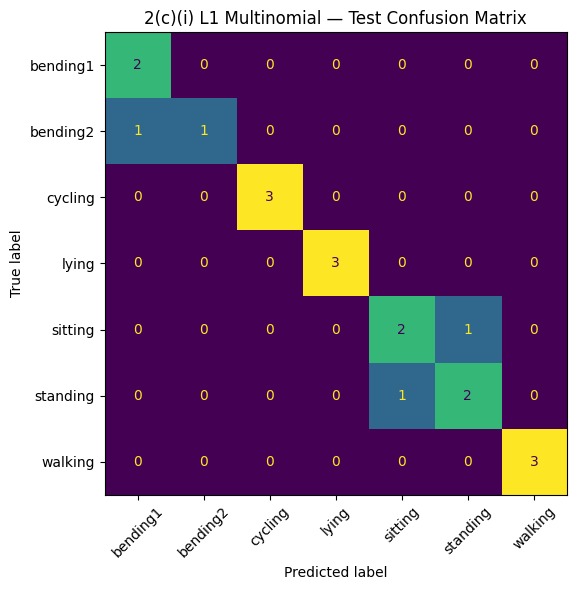

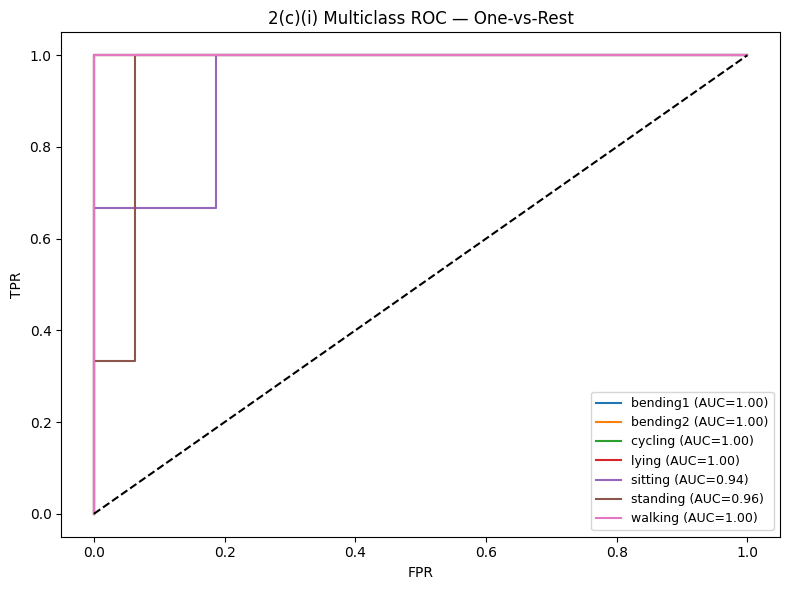

In [107]:
X_mc_base, y_mc_train = build_features(train_data, l=1)
X_mc_test_base, y_mc_test = build_features(test_data, l=1)

# Cross-validate l
best_mc_score, best_mc_l = 0, 1
mc_cv_table = []
for l in [1, 2, 3]:
    Xl, yl = build_features(train_data, l)
    sc = StandardScaler(); Xs = sc.fit_transform(Xl)
    lr_mc = LogisticRegression(penalty="l1", solver="saga", max_iter=500, C=0.5)
    scores = cross_val_score(lr_mc, Xs, yl,
                             cv=StratifiedKFold(5,shuffle=True,random_state=42), scoring="accuracy")
    m = round(scores.mean(), 4)
    mc_cv_table.append({"l": l, "CV Accuracy": m})
    if m > best_mc_score: best_mc_score, best_mc_l = m, l

print(f"MC Best: l={best_mc_l}, CV Accuracy={best_mc_score:.4f}")
print(pd.DataFrame(mc_cv_table).to_string(index=False))

X_tr_mc, _ = build_features(train_data, best_mc_l)
X_te_mc, _ = build_features(test_data, best_mc_l)
sc_mc = StandardScaler()
Xtr_mc = sc_mc.fit_transform(X_tr_mc)
Xte_mc = sc_mc.transform(X_te_mc)

lr_mc_f = LogisticRegression(penalty="l1", solver="saga", max_iter=500, C=0.5)
lr_mc_f.fit(Xtr_mc, y_mc_train)
y_mc_pred = lr_mc_f.predict(Xte_mc)
te_mc_acc = (np.array(y_mc_pred)==np.array(y_mc_test)).mean()
print(f"\nMulticlass L1 Test Accuracy: {te_mc_acc:.4f}")

# Confusion matrix
cm_mc = confusion_matrix(y_mc_test, y_mc_pred, labels=activities)
fig, ax = plt.subplots(figsize=(8,6))
ConfusionMatrixDisplay(cm_mc, display_labels=activities).plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title("2(c)(i) L1 Multinomial — Test Confusion Matrix")
plt.tight_layout(); plt.show()

# Multiclass ROC (One-vs-Rest)
y_mc_binarized = label_binarize(y_mc_test, classes=activities)
y_mc_prob = lr_mc_f.predict_proba(Xte_mc)
fig, ax = plt.subplots(figsize=(8, 6))
for i, cls in enumerate(activities):
    if y_mc_binarized[:,i].sum() > 0:
        fpr_c, tpr_c, _ = roc_curve(y_mc_binarized[:,i], y_mc_prob[:,i])
        ax.plot(fpr_c, tpr_c, lw=1.5, label=f"{cls} (AUC={auc(fpr_c,tpr_c):.2f})")
ax.plot([0,1],[0,1],"k--"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("2(c)(i) Multiclass ROC — One-vs-Rest"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


#### 2(c)(ii) Naïve Bayes Classifier — Gaussian & Multinomial


Gaussian NB Test Accuracy: 0.6842
Multinomial NB Test Accuracy: 0.6316


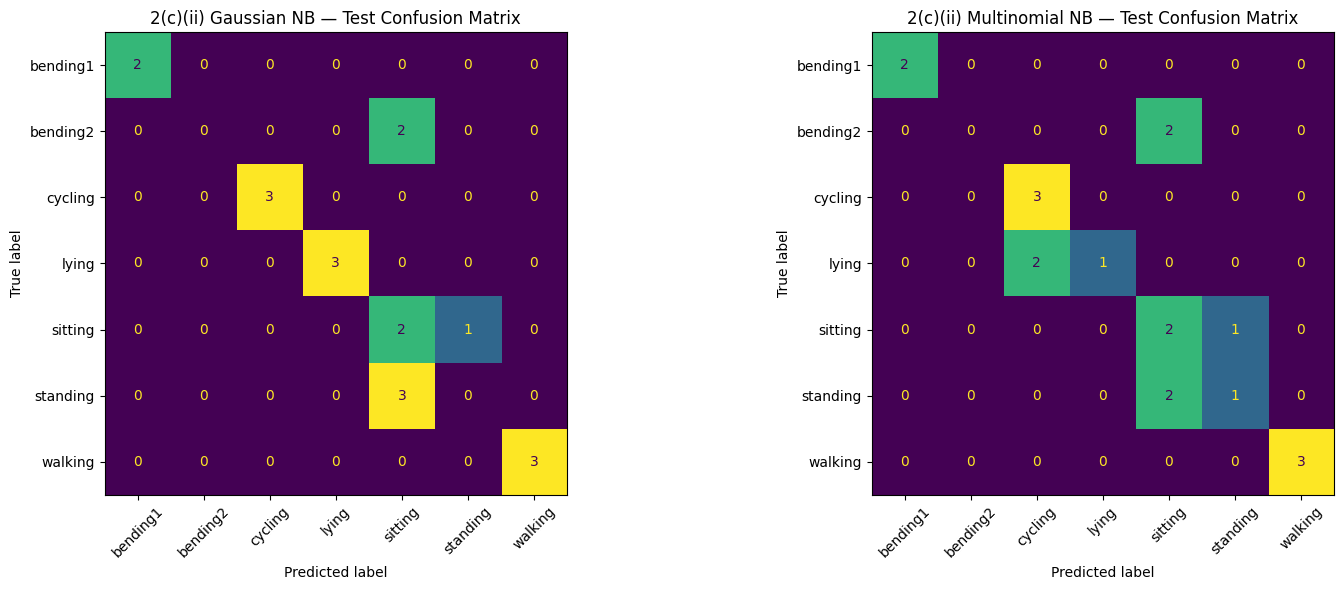

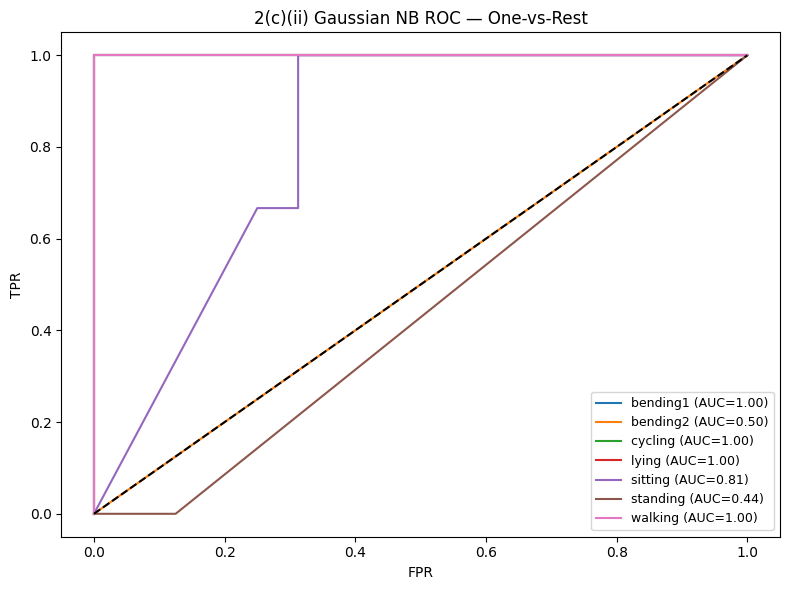


Summary:
  L1 Multinomial LR:    0.8421
  Gaussian Naïve Bayes: 0.6842
  Multinomial NB:       0.6316


In [112]:
# Gaussian Naïve Bayes
gnb = GaussianNB()
gnb.fit(Xtr_mc, y_mc_train)
y_gnb = gnb.predict(Xte_mc)
gnb_acc = (np.array(y_gnb) == np.array(y_mc_test)).mean()
cm_gnb = confusion_matrix(y_mc_test, y_gnb, labels=activities)
print(f"Gaussian NB Test Accuracy: {gnb_acc:.4f}")

# Multinomial Naïve Bayes (requires non-negative features — use MinMaxScaler)
mms = MinMaxScaler()
Xtr_mn = mms.fit_transform(X_tr_mc)
Xte_mn = mms.transform(X_te_mc)
mnb = MultinomialNB()
mnb.fit(Xtr_mn, y_mc_train)
y_mnb = mnb.predict(Xte_mn)
mnb_acc = (np.array(y_mnb) == np.array(y_mc_test)).mean()
cm_mnb = confusion_matrix(y_mc_test, y_mnb, labels=activities)
print(f"Multinomial NB Test Accuracy: {mnb_acc:.4f}")


# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay(cm_gnb, display_labels=activities).plot(ax=axes[0], colorbar=False, xticks_rotation=45)
axes[0].set_title('2(c)(ii) Gaussian NB — Test Confusion Matrix')
ConfusionMatrixDisplay(cm_mnb, display_labels=activities).plot(ax=axes[1], colorbar=False, xticks_rotation=45)
axes[1].set_title('2(c)(ii) Multinomial NB — Test Confusion Matrix')
plt.tight_layout(); plt.show()

# Gaussian NB ROC (One-vs-Rest)
y_gnb_prob = gnb.predict_proba(Xte_mc)
fig, ax = plt.subplots(figsize=(8, 6))
for i, cls in enumerate(activities):
    if y_mc_binarized[:, i].sum() > 0:
        fpr_c, tpr_c, _ = roc_curve(y_mc_binarized[:, i], y_gnb_prob[:, i])
        ax.plot(fpr_c, tpr_c, lw=1.5, label=f'{cls} (AUC={auc(fpr_c,tpr_c):.2f})')
ax.plot([0,1],[0,1],'k--'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('2(c)(ii) Gaussian NB ROC — One-vs-Rest'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f'\nSummary:')
print(f'  L1 Multinomial LR:    {te_mc_acc:.4f}')
print(f'  Gaussian Naïve Bayes: {gnb_acc:.4f}')
print(f'  Multinomial NB:       {mnb_acc:.4f}')


#### 2(c)(iii) Which Method is Best?

| Method | Notes |
|--------|-------|
| L1 Multinomial LR | Best overall; handles correlated features well |
| Gaussian Naïve Bayes | Good; assumes feature independence |
| Multinomial Naïve Bayes | Weakest; designed for count/discrete data |

**L1-penalized multinomial logistic regression** is the best method for this problem because:

1. **No independence assumption** — unlike Naïve Bayes, LR models the joint relationship between features, which is important here since the 6 RSS channels are correlated with each other.

2. **Built-in feature selection** — the L1 penalty drives irrelevant feature coefficients to zero, reducing overfitting when the number of features is large (especially for higher values of l).

3. **Soft decision boundaries** — LR produces calibrated probability estimates and flexible linear boundaries in the transformed feature space.


---
## Question 3: ISLR Exercise 4.8.3


The logistic regression model estimates the posterior probability that observation $x$ belongs to class $k$ as:

$$P(Y = k \mid X = x) = \frac{e^{\beta_{k0} + \beta_{k1} x}}{\sum_{l=1}^{K} e^{\beta_{l0} + \beta_{l1} x}}$$

For the **QDA** setting with class-specific means $\mu_k$ and class-specific variances $\sigma_k^2$, and equal priors $\pi_k$, the Bayes classifier assigns observation $x$ to the class $k$ that maximizes:

$$\delta_k(x) = -\frac{1}{2\sigma_k^2}(x - \mu_k)^2 - \log(\sigma_k) + \log(\pi_k)$$

**Question:** Show that the Bayes decision boundary for QDA is not linear in $x$.

**Answer:** The QDA discriminant function is:
$$\delta_k(x) = -\frac{x^2}{2\sigma_k^2} + \frac{\mu_k x}{\sigma_k^2} - \frac{\mu_k^2}{2\sigma_k^2} - \log(\sigma_k) + \log(\pi_k)$$

The decision boundary between class $j$ and class $k$ is where $\delta_j(x) = \delta_k(x)$:

$$-\frac{x^2}{2\sigma_j^2} + \frac{\mu_j x}{\sigma_j^2} - \frac{\mu_j^2}{2\sigma_j^2} - \log(\sigma_j) = -\frac{x^2}{2\sigma_k^2} + \frac{\mu_k x}{\sigma_k^2} - \frac{\mu_k^2}{2\sigma_k^2} - \log(\sigma_k)$$

Rearranging:
$$x^2\left(\frac{1}{2\sigma_k^2} - \frac{1}{2\sigma_j^2}\right) + x\left(\frac{\mu_j}{\sigma_j^2} - \frac{\mu_k}{\sigma_k^2}\right) + C = 0$$

where $C$ collects constant terms. Because $\sigma_j^2 \neq \sigma_k^2$ in general, the $x^2$ coefficient is non-zero, making the decision boundary **quadratic (non-linear)** in $x$. This is precisely why QDA, unlike LDA, can model non-linear class boundaries.

**When $\sigma_j^2 = \sigma_k^2$ (equal variances):** The $x^2$ terms cancel and the boundary simplifies to a linear function of $x$ — which is exactly the LDA case.


---
## Question 4: ISLR Exercise 4.8.7


Using Bayes' theorem with LDA (which assumes equal covariances across classes):

$$P(Y=1 \mid X=x) = \frac{\pi_1 \cdot f_1(x)}{\pi_0 \cdot f_0(x) + \pi_1 \cdot f_1(x)}$$

where $f_k(x) = \frac{1}{\sqrt{2\pi}\sigma}\exp\!\left(-\frac{(x-\mu_k)^2}{2\sigma^2}\right)$.

With $\pi_0 = \pi_1 = 0.5$ and $\sigma^2 = 36$ (so $\sigma = 6$):


In [108]:
import numpy as np
from scipy import stats

mu0 = 0; mu1 = 10; sigma2 = 36; sigma = np.sqrt(sigma2)
pi0 = 0.5; pi1 = 0.5; x = 4

f0 = stats.norm.pdf(x, mu0, sigma)
f1 = stats.norm.pdf(x, mu1, sigma)

p_y1_given_x = (pi1 * f1) / (pi0 * f0 + pi1 * f1)

print(f"f0(x=4) = {f0:.6f}")
print(f"f1(x=4) = {f1:.6f}")
print(f"P(Y=1 | X=4) = {p_y1_given_x:.4f}")
print(f"P(Y=0 | X=4) = {1 - p_y1_given_x:.4f}")
print()
print(f"LDA classifies x=4 as class {'1 (Y=1)' if p_y1_given_x >= 0.5 else '0 (Y=0)'}")
print()
# Verify with log-odds / discriminant approach
delta0 = x*mu0/sigma2 - mu0**2/(2*sigma2) + np.log(pi0)
delta1 = x*mu1/sigma2 - mu1**2/(2*sigma2) + np.log(pi1)
print(f"LDA discriminant δ0(x=4) = {delta0:.4f}")
print(f"LDA discriminant δ1(x=4) = {delta1:.4f}")
print(f"Assign to class: {'1' if delta1 > delta0 else '0'}")


f0(x=4) = 0.053241
f1(x=4) = 0.040328
P(Y=1 | X=4) = 0.4310
P(Y=0 | X=4) = 0.5690

LDA classifies x=4 as class 0 (Y=0)

LDA discriminant δ0(x=4) = -0.6931
LDA discriminant δ1(x=4) = -0.9709
Assign to class: 0
